In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import webbrowser
from cv2 import cvtColor,resize

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Image Preprocessing 

# 1) Original Image Pixel compression

As K-means models typically runs in O(n * k * d) time complexity, where:

    n is the number of samples,

    k is the number of clusters,

    d is the number of dimensions (features) of each data point.

We have that a reduction of sample number by means of compression can lower the computational time by a factor of 1/n.

Thus we choose to compress the image to 200x200 pixels, still retaining the main needed information - that is, the color of the image.

(4080, 2296, 3)


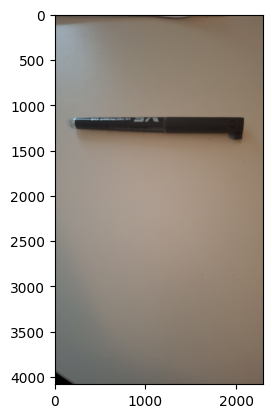

In [2]:
# Step 1: Load the image
image_path = 'data/20250327_171942.jpg'
image = cv.imread(image_path)

# Convert from BGR to RGB
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
print(image_rgb.shape)
plt.imshow(image_rgb)
plt.show()
plt.close()

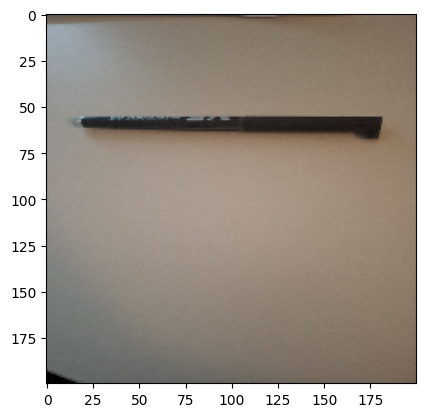

In [3]:
image_resized=cv.resize(image_rgb,(200,200  )) #resize image for faster processing

plt.imshow(image_resized)
plt.show()
plt.close()

## Image Preprocessing 

# 2) 



In [4]:
#we reshape xy pixels of the image into 1D vector of length nx * ny for point classification
reshaped_image=image_resized.reshape(-1,3)

<Figure size 640x480 with 0 Axes>

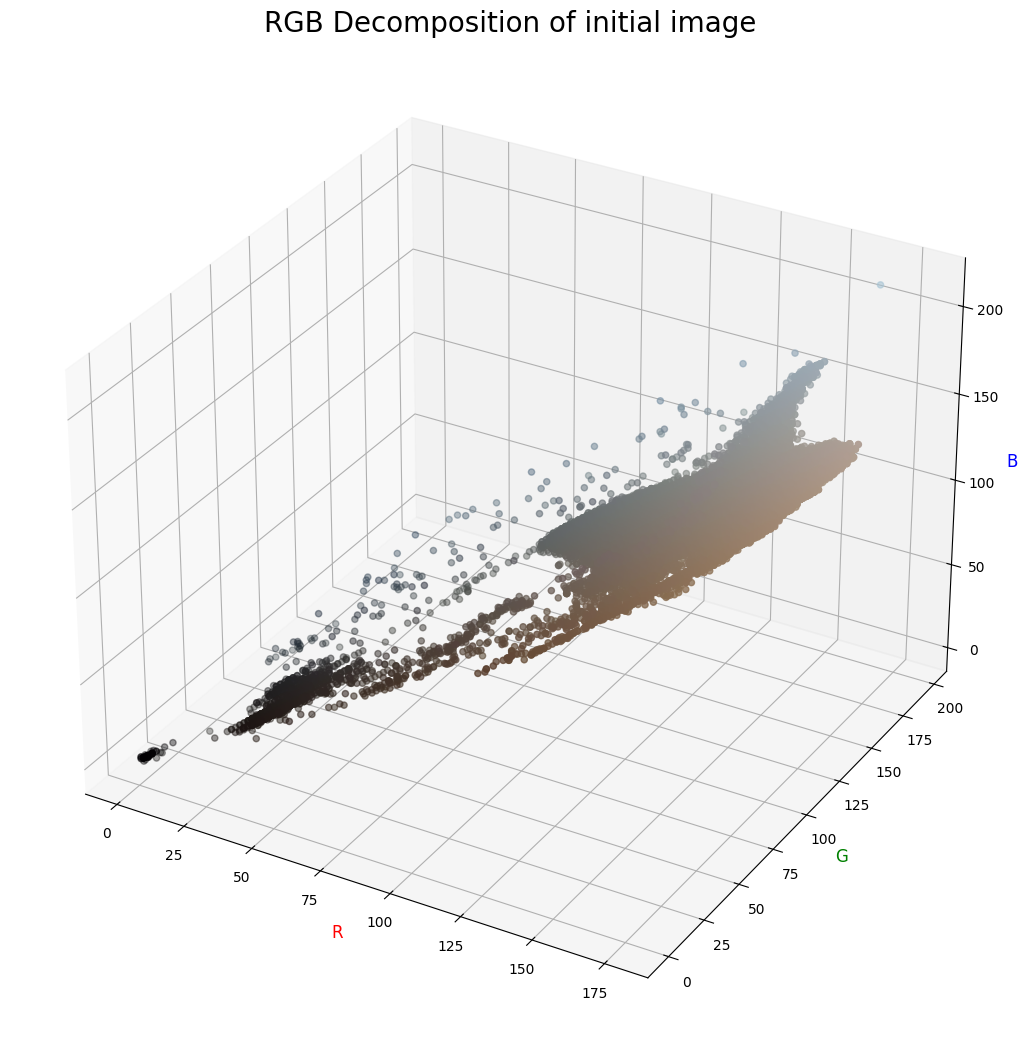

<Figure size 640x480 with 0 Axes>

In [5]:
#initialise color lists
red=[]
green=[]
blue=[]

for index,element in enumerate(reshaped_image) :
    red.append(reshaped_image[index][0])
    green.append(reshaped_image[index][1])
    blue.append(reshaped_image[index][2])

#convert lists into array for subsequent RGB color plotting

red=np.array(red)
green=np.array(green)
blue=np.array(blue)

#3d plot

plt.clf() #clear previous image to prevent cache overflow

fig1 = plt.figure(figsize=(13,13))
ax = fig1.add_subplot(111, projection='3d')
ax.set_xlabel('R',color="r", fontsize=12)
ax.set_ylabel('G',color="g", fontsize=12)
ax.set_zlabel('B',color="b", fontsize=12)
ax.scatter(red, green, blue,c=np.stack((red/255, green/255, blue/255), axis=-1), marker='o')

plt.title("RGB Decomposition of initial image",fontsize=20)
plt.show()
plt.close()
plt.clf()

## Image Preprocessing 

# 3) 



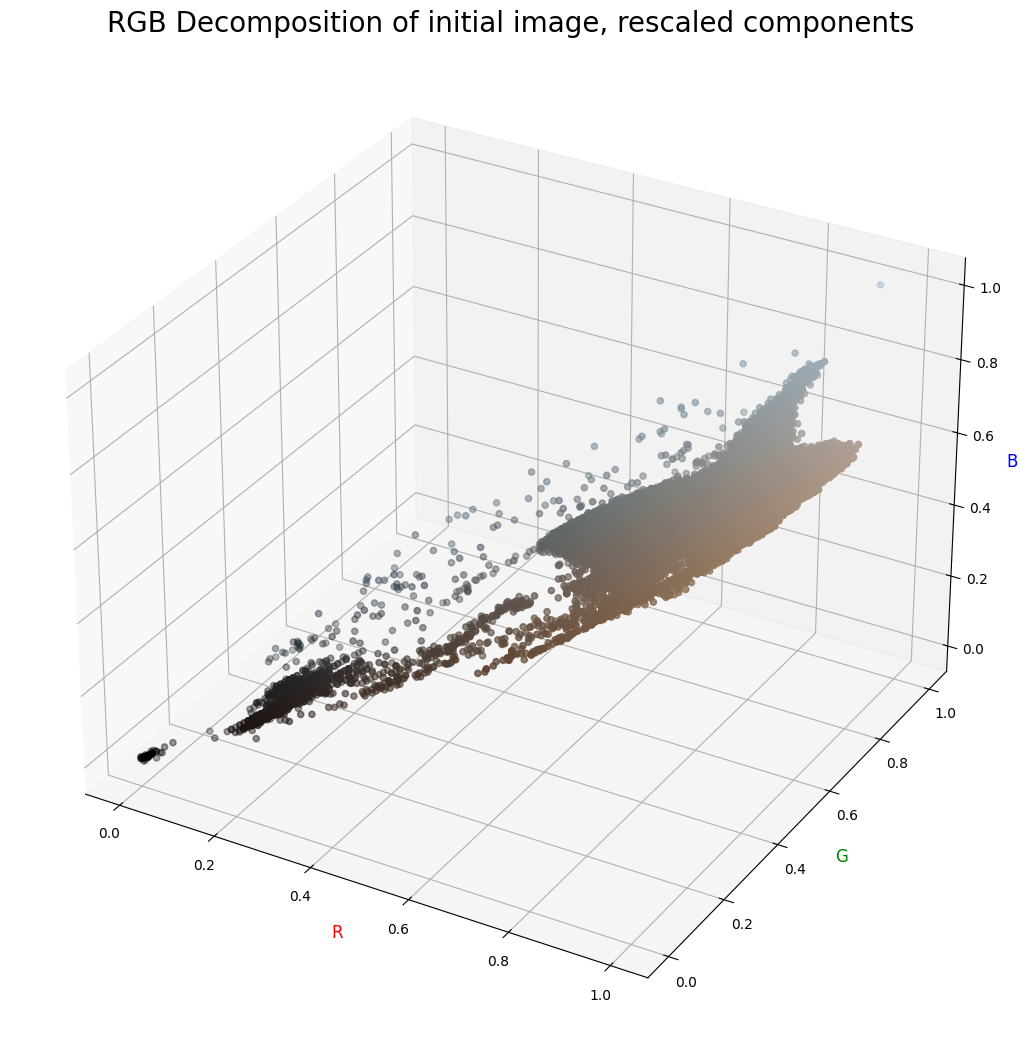

<Figure size 640x480 with 0 Axes>

In [6]:
scaler=MinMaxScaler()

red_transf = MinMaxScaler().fit_transform(red.reshape(-1,1))
green_transf =MinMaxScaler().fit_transform(green.reshape(-1,1))
blue_transf= MinMaxScaler().fit_transform(blue.reshape(-1,1))


fig2 = plt.figure(figsize=(13,13))
ax = fig2.add_subplot(111, projection='3d')

ax.scatter(red_transf, green_transf, blue_transf,c=np.stack((red/255, green/255, blue/255), axis=-1), marker='o')
ax.set_xlabel('R',color="r", fontsize=12)
ax.set_ylabel('G',color="g", fontsize=12)
ax.set_zlabel('B',color="b", fontsize=12)

plt.title("RGB Decomposition of initial image, rescaled components",fontsize=20)
plt.show()
plt.close()
plt.clf()

## K-Means Model

Exploratory analysis: we choose a max number of 10 K-means centroids and we evaluate the inertia of the chosen clusters and their silhouette values; this should give us an idea of how the data in the image is distributed and what is the approximate best value for k

In [ ]:
X=scaler.fit_transform(reshaped_image)
k_range = range(2,11)
k_cycle=[]
k_index=[]
k_inertia=[]
silhouette=[]
centroids_k=[]
labels_k=[]
for k in k_range:
    print (f"cycle number is {k}")
    k_index.append(k)
    model = KMeans (n_clusters=k,random_state=42,init="random",max_iter=500)
    model.fit(X)
    centroids_k.append(model.cluster_centers_)  # Get cluster centers
    labels_k.append(model.labels_)  # Get labels for each point
    k_inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, model.labels_, metric='euclidean'))
    # Apply the elbow method to find the optimal number of clusters.

#lookup https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html#sklearn.metrics.silhouette_score
#for automatic inflection point evaluation in elbow method

cycle number is 2


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 3


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 4


...

/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 9


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cycle number is 10


/home/lorezinn/.pyenv/versions/taxifare-env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


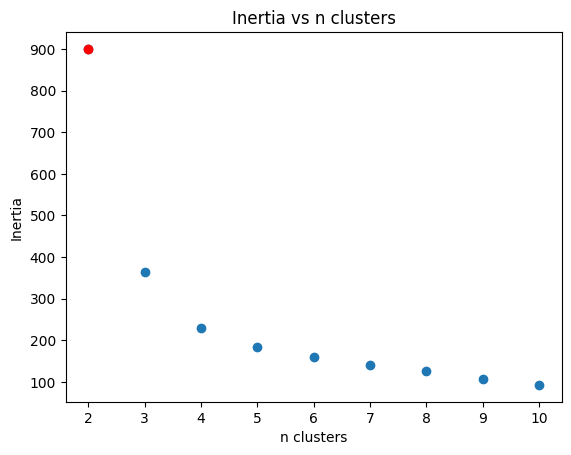

In [8]:
# YOUR CODE HERE
plt.clf()
maxsil=max(silhouette)
indexk=silhouette.index(maxsil)
plt.scatter(k_index,k_inertia)
plt.scatter(k_index[indexk],k_inertia[indexk],c="r")
plt.title("Inertia vs n clusters")
plt.xlabel("n clusters")
plt.ylabel("Inertia")
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

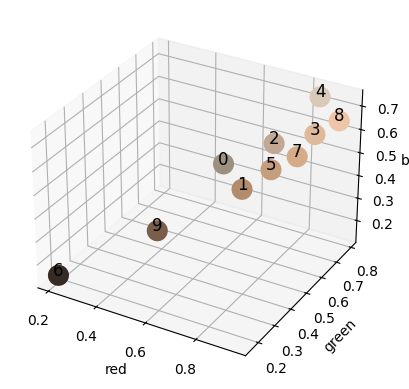

In [22]:
plt.clf()

max_centroids = centroids_k[-1]
red_centroid=[]
green_centroid=[]
blue_centroid=[]
for k in range(len(max_centroids)):
    red_centroid.append(max_centroids[k][0])
    green_centroid.append(max_centroids[k][1])
    blue_centroid.append(max_centroids[k][2])

red2=np.array(red_centroid)
green2=np.array(green_centroid)
blue2=np.array(blue_centroid)


fig4 = plt.figure()
ax = fig4.add_subplot(111, projection='3d')

ax.scatter(red2, green2, blue2,c=np.stack((red2, green2, blue2), axis=-1),s=200, marker='o',alpha=1)

for i in range(len(red2)):
    ax.text(red2[i], green2[i], blue2[i], f'{i}', color='black', fontsize=12, ha='center')

ax.set_xlabel('red')
ax.set_ylabel('green')
ax.set_zlabel('blue')


plt.show()
plt.close()

In [23]:
# Step 5: Count the number of pixels in each cluster
#NOTE find the one with max counts -> it is the chosen RGB
#NOTE 2 from the 3 main colors create small rectangular boxes corresponding
#to the 3 main colors, along with their percentage
unique, counts = np.unique(labels_k, return_counts=True)
maxcounts=max(counts)
labelmax=counts.argmax()
total=counts.sum()
percentage_counts=counts/total
percentage_counts*100


array([23.40444444, 15.335     , 20.415     , 12.22277778,  4.73527778,
       10.36777778,  4.57194444,  4.38611111,  4.45111111,  0.11055556])

In [ ]:
#convert dataframe column of the format rrr-ggg-bbb into[rrr,ggg,bbb]
def convert_to_list(color_string):
    return np.array(list(map(int, color_string.split('-'))))

def find_RAL(centroid_colors):
    RAL_df = pd.read_csv("ral_classic.csv") #create dataframe from RAL table
    # Apply the conversion to the RGB column
    RAL_df['RGB_converted'] = RAL_df['RGB'].apply(convert_to_list).copy()


    """KMeans model to find closest (n=1) label"""
    X = np.array(RAL_df['RGB_converted'].tolist())  # Convert the lists to a 2D array (n_samples x 3 features)
    Y = RAL_df['RAL'].copy()  # Target variable (1D)


    classifier = KNeighborsClassifier(n_neighbors=1)
    classifier.fit(X=X,y=Y)

    predicted_RAL_code=classifier.predict(np.array([centroid_colors])) #this is the chosen ral
    predicted_RAL_text=RAL_df.loc[RAL_df['RAL'] == predicted_RAL_code[0], 'English'].iloc[0]

    return predicted_RAL_code,predicted_RAL_text


In [ ]:
color_df = pd.read_csv("ral_classic.csv")
color_df.head(10)


,RAL,RGB,HEX,CMYK,LRV,English,German,French,Spanish,Italian,Dutch
0,RAL 1000,205-186-136,#CDBA88,0-9-34-20,51.79,Green beige,Grünbeige,Beige vert,Beige verdoso,Beige verdastro,Groenbeige
1,RAL 1001,208-176-132,#D0B084,0-15-37-18,48.09,Beige,Beige,Beige,Beige,Beige,Beige
2,RAL 1002,210-170-109,#D2AA6D,0-19-48-18,45.07,Sand yellow,Sandgelb,Jaune sable,Amarillo arena,Giallo sabbia,Zandgeel
3,RAL 1003,249-169-0,#F9A900,0-32-100-2,49.05,Signal yellow,Signalgelb,Jaune de sécurité,Amarillo señales,Giallo segnale,Signaalgeel
4,RAL 1004,228-158-0,#E49E00,0-31-100-11,42.13,Golden yellow,Goldgelb,Jaune or,Amarillo oro,Giallo oro,Goudgeel
5,RAL 1005,203-143-0,#CB8F00,0-30-100-20,34.15,Honey yellow,Honiggelb,Jaune miel,Amarillo miel,Giallo miele,Honinggeel
6,RAL 1006,225-144-0,#E19000,0-36-100-12,37.45,Maize yellow,Maisgelb,Jaune maïs,Amarillo maíz,Giallo polenta,Maisgeel
7,RAL 1007,232-140-0,#E88C00,0-40-100-9,37.63,Daffodil yellow,Narzissengelb,Jaune narcisse,Amarillo narciso,Giallo narciso,Narcissengeel
8,RAL 1011,175-128-80,#AF8050,0-27-54-31,27.65,Brown beige,Braunbeige,Beige brun,Beige pardo,Beige marrone,Bruinbeige
9,RAL 1012,221-175-40,#DDAF28,0-21-82-13,47.83,Lemon yellow,Zitronengelb,Jaune citron,Amarillo limón,Giallo limone,Citroengeel


In [24]:
def convert_to_list(color_string):
    return np.array(list(map(int, color_string.split('-'))))

# Apply the conversion to the column
color_df['RGB_converted'] = color_df['RGB'].apply(convert_to_list).copy()
rgb_array = np.array(color_df["RGB"]).copy()
color_df.head(10)


,RAL,RGB,HEX,CMYK,LRV,English,German,French,Spanish,Italian,Dutch,RGB_converted
0,RAL 1000,205-186-136,#CDBA88,0-9-34-20,51.79,Green beige,Grünbeige,Beige vert,Beige verdoso,Beige verdastro,Groenbeige,"[205, 186, 136]"
1,RAL 1001,208-176-132,#D0B084,0-15-37-18,48.09,Beige,Beige,Beige,Beige,Beige,Beige,"[208, 176, 132]"
2,RAL 1002,210-170-109,#D2AA6D,0-19-48-18,45.07,Sand yellow,Sandgelb,Jaune sable,Amarillo arena,Giallo sabbia,Zandgeel,"[210, 170, 109]"
3,RAL 1003,249-169-0,#F9A900,0-32-100-2,49.05,Signal yellow,Signalgelb,Jaune de sécurité,Amarillo señales,Giallo segnale,Signaalgeel,"[249, 169, 0]"
4,RAL 1004,228-158-0,#E49E00,0-31-100-11,42.13,Golden yellow,Goldgelb,Jaune or,Amarillo oro,Giallo oro,Goudgeel,"[228, 158, 0]"
5,RAL 1005,203-143-0,#CB8F00,0-30-100-20,34.15,Honey yellow,Honiggelb,Jaune miel,Amarillo miel,Giallo miele,Honinggeel,"[203, 143, 0]"
6,RAL 1006,225-144-0,#E19000,0-36-100-12,37.45,Maize yellow,Maisgelb,Jaune maïs,Amarillo maíz,Giallo polenta,Maisgeel,"[225, 144, 0]"
7,RAL 1007,232-140-0,#E88C00,0-40-100-9,37.63,Daffodil yellow,Narzissengelb,Jaune narcisse,Amarillo narciso,Giallo narciso,Narcissengeel,"[232, 140, 0]"
8,RAL 1011,175-128-80,#AF8050,0-27-54-31,27.65,Brown beige,Braunbeige,Beige brun,Beige pardo,Beige marrone,Bruinbeige,"[175, 128, 80]"
9,RAL 1012,221-175-40,#DDAF28,0-21-82-13,47.83,Lemon yellow,Zitronengelb,Jaune citron,Amarillo limón,Giallo limone,Citroengeel,"[221, 175, 40]"


In [27]:
X = np.array(color_df['RGB_converted'].tolist())  # Convert the lists to a 2D array (n_samples x 3 features)

In [18]:
X = np.array(color_df['RGB_converted'].tolist())  # Convert the lists to a 2D array (n_samples x 3 features)
Y = color_df['RAL'].copy()  # Target variable (1D)

classifier = KNeighborsClassifier(n_neighbors=1)
classifier.fit(X=X,y=Y)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
predicted_RAL_code=classifier.predict(np.array([[241, 197, 166]])) #this is the chosen ral
predicted_RAL_text=color_df.loc[color_df['RAL'] == predicted_RAL_code[0], 'English'].iloc[0]

print(predicted_RAL_code,predicted_RAL_text)

['RAL 1015'] Light ivory


In [ ]:
# Set the preset search query
search_query = str(predicted_RAL_text) + str(predicted_RAL_code) + " table spray"

# Construct the search URL for Google
url = f"https://www.google.com/search?q={search_query}"

# Open the URL in the default web browser
webbrowser.open(url)


[6156:16032:0411/164452.057:ERROR:registration_request.cc(291)] Registration response error message: DEPRECATED_ENDPOINT
Created TensorFlow Lite XNNPACK delegate for CPU.
Attempting to use a delegate that only supports static-sized tensors with a graph that has dynamic-sized tensors (tensor#-1 is a dynamic-sized tensor).
[6156:16032:0411/164520.738:ERROR:registration_request.cc(291)] Registration response error message: DEPRECATED_ENDPOINT
[6156:16032:0411/164617.620:ERROR:registration_request.cc(291)] Registration response error message: DEPRECATED_ENDPOINT
[6156:16032:0411/164742.875:ERROR:registration_request.cc(291)] Registration response error message: DEPRECATED_ENDPOINT
[6156:16032:0411/165057.575:ERROR:registration_request.cc(291)] Registration response error message: DEPRECATED_ENDPOINT


KeyboardInterrupt: 